> #### Environment Setup
> Copy the following line to the terminal
> ```cmd
> pip install matplotlib seaborn numpy scipy scikit-learn tensorflow yfinance
> ```

# Plan
1. Fetch Data
2. Generate All Candidate Features (technical indicators, returns, ratios, time)
3. Feature Selection — correlation filter (Pearson > 0.25) → Lasso with TimeSeriesSplit (5-fold, keep if selected in ≥2/3 splits)
4. Data Preparation — selected features, train/val/test split before scaling, RobustScaler, sequence creation (lookback=60)
5. Hyperparameter Tuning — KerasTuner Hyperband over LSTM units, dropout, learning rate
6. Build & Train LSTM — two LSTM layers with Dropout, EarlyStopping
7. MC Dropout Prediction + Conformal Prediction calibration on validation set
8. Visualize — actual vs predicted with 95% conformal bands
9. Evaluate — RMSE, MAE, MAPE, conformal coverage


# 0. Configuration

In [2]:
%pip install matplotlib seaborn pandas numpy scipy scikit-learn xgboost statsmodels tensorflow yfinance
import yfinance as yf
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import Lasso
from xgboost import XGBRegressor
from statsmodels.tsa.stattools import grangercausalitytests
from sklearn.model_selection import TimeSeriesSplit
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import mean_squared_error

%pip install keras-tuner tensorboard -q
import keras_tuner as kt
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Input
from keras.callbacks import EarlyStopping
import keras

# Plan
1. Fetch Data
2. Generate All Candidate Features (technical indicators, returns, ratios, time)
3. Feature Selection — correlation filter (Pearson > 0.25) → Lasso with TimeSeriesSplit (5-fold, keep if selected in ⅔ splits) → XGBoost importance (non-linear) → Granger casuality + Lagged correlation (temporal, linear)
4. Data Preparation — selected features, train/val/test split before scaling, RobustScaler, sequence creation (lookback=60)
5. Hyperparameter Tuning — KerasTuner Hyperband over LSTM units, dropout, learning rate
6. Build & Train LSTM — two LSTM layers with Dropout, EarlyStopping
7. MC Dropout Prediction + Conformal Prediction calibration on validation set
8. Visualize — actual vs predicted with 95% conformal bands
9. Evaluate — RMSE, MAE, MAPE, conformal coverage

In [3]:
stock_data = yf.download('TSLA', start='2016-01-01', multi_level_index=False)
stock_data

[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2016-01-04,14.894000,15.425333,14.600000,15.381333,102406500
2016-01-05,14.895333,15.126000,14.666667,15.090667,47802000
2016-01-06,14.602667,14.670000,14.398667,14.666667,56686500
2016-01-07,14.376667,14.562667,14.244667,14.279333,53314500
2016-01-08,14.066667,14.696000,14.051333,14.524000,54421500
...,...,...,...,...,...
2026-06-16,404.660004,412.420013,400.540009,404.109985,40255500
2026-06-17,396.380005,405.940002,393.760010,401.529999,43534300
2026-06-18,400.489990,402.519989,384.700012,398.100006,58384700


---
# 2. Generate All Candidate Features

In [4]:
df = stock_data.copy()
# --- Technical indicators ---
for w in [5, 10, 20, 50]:
    df[f'EMA_{w}']    = df['Close'].ewm(span=w).mean()
    df[f'Volatility_{w}'] = df['Close'].pct_change().rolling(w).std()

df['RSI_14'] = 100 - 100 / (1 + df['Close'].diff().clip(lower=0).rolling(14).mean() /
                             df['Close'].diff().clip(upper=0).abs().rolling(14).mean())

ema12 = df['Close'].ewm(span=12).mean()
ema26 = df['Close'].ewm(span=26).mean()
df['MACD']         = ema12 - ema26
df['MACD_signal']  = df['MACD'].ewm(span=9).mean()
df['MACD_hist']    = df['MACD'] - df['MACD_signal']

sma20 = df['Close'].rolling(20).mean()
std20 = df['Close'].rolling(20).std()
df['BB_upper'] = sma20 + 2 * std20
df['BB_lower'] = sma20 - 2 * std20
df['BB_width'] = (df['BB_upper'] - df['BB_lower']) / sma20

high_low  = df['High'] - df['Low']
high_prev = (df['High'] - df['Close'].shift(1)).abs()
low_prev  = (df['Low']  - df['Close'].shift(1)).abs()
df['ATR_14'] = pd.concat([high_low, high_prev, low_prev], axis=1).max(axis=1).rolling(14).mean()

df['OBV'] = (np.sign(df['Close'].diff()) * df['Volume']).cumsum()

# --- Returns ---
df['log_return']   = np.log(df['Close'] / df['Close'].shift(1))
df['return_1d']    = df['Close'].pct_change()
df['return_5d']    = df['Close'].pct_change(5)

# --- Price ratios ---
df['high_low_ratio']  = df['High'] / df['Low']
df['close_open_ratio'] = df['Close'] / df['Open']

# --- Time features ---
# Year
year_days = df.index.is_leap_year * 366 + (~df.index.is_leap_year) * 365
df['sin_year'] = np.sin(2 * np.pi * (df.index.dayofyear - 1) / year_days)
df['cos_year'] = np.cos(2 * np.pi * (df.index.dayofyear - 1) / year_days)
df['day_of_week'] = df.index.dayofweek / 6.0

# Week (52 weeks)
df['sin_week'] = np.sin(2 * np.pi * (df.index.isocalendar().week - 1) / 52)
df['cos_week'] = np.cos(2 * np.pi * (df.index.isocalendar().week - 1) / 52)

# Month (12 months)
df['sin_month'] = np.sin(2 * np.pi * (df.index.month - 1) / 12)
df['cos_month'] = np.cos(2 * np.pi * (df.index.month - 1) / 12)

# Quarter (4 quarters)
df['sin_quarter'] = np.sin(2 * np.pi * (df.index.quarter - 1) / 4)
df['cos_quarter'] = np.cos(2 * np.pi * (df.index.quarter - 1) / 4)

# Linear trend feature
df = df.reset_index()  # Creates a 'Date' column with datetime values, numeric index
df['days_since_start'] = (df['Date'] - df['Date'].iloc[0]).dt.days.astype(float)

# --- Target ---
df['Close_nxt'] = df['Close'].shift(-1)
df = df.dropna()
df = df.drop(columns=['Date'])

feature_cols = [c for c in df.columns if c not in ['Close_nxt']]
target_col = ['Close_nxt']
print(f"{len(feature_cols)} candidate features:\n{feature_cols}")

37 candidate features:
['Close', 'High', 'Low', 'Open', 'Volume', 'EMA_5', 'Volatility_5', 'EMA_10', 'Volatility_10', 'EMA_20', 'Volatility_20', 'EMA_50', 'Volatility_50', 'RSI_14', 'MACD', 'MACD_signal', 'MACD_hist', 'BB_upper', 'BB_lower', 'BB_width', 'ATR_14', 'OBV', 'log_return', 'return_1d', 'return_5d', 'high_low_ratio', 'close_open_ratio', 'sin_year', 'cos_year', 'day_of_week', 'sin_week', 'cos_week', 'sin_month', 'cos_month', 'sin_quarter', 'cos_quarter', 'days_since_start']


---
# 3. Feature Selection

In [5]:
'''Sample split and Other Configuration'''
# Prepare data (using only features, not target)
X_temp = df[feature_cols].values
y = df[target_col].values

# Getting a sample of the data
sample_len = int(len(X_temp)*0.5)
X_sample = X_temp[:sample_len]
y_sample = y[:sample_len]
sample_df = df.iloc[:sample_len].copy()

print(X_sample.shape, y_sample.shape)

# Scale features (separate scaler for train/test)
scaler = RobustScaler()
X_sample_scaled = scaler.fit_transform(X_sample)

(1290, 37) (1290, 1)


Before target filter, 37 features: ['Close', 'High', 'Low', 'Open', 'Volume', 'EMA_5', 'Volatility_5', 'EMA_10', 'Volatility_10', 'EMA_20', 'Volatility_20', 'EMA_50', 'Volatility_50', 'RSI_14', 'MACD', 'MACD_signal', 'MACD_hist', 'BB_upper', 'BB_lower', 'BB_width', 'ATR_14', 'OBV', 'log_return', 'return_1d', 'return_5d', 'high_low_ratio', 'close_open_ratio', 'sin_year', 'cos_year', 'day_of_week', 'sin_week', 'cos_week', 'sin_month', 'cos_month', 'sin_quarter', 'cos_quarter', 'days_since_start']


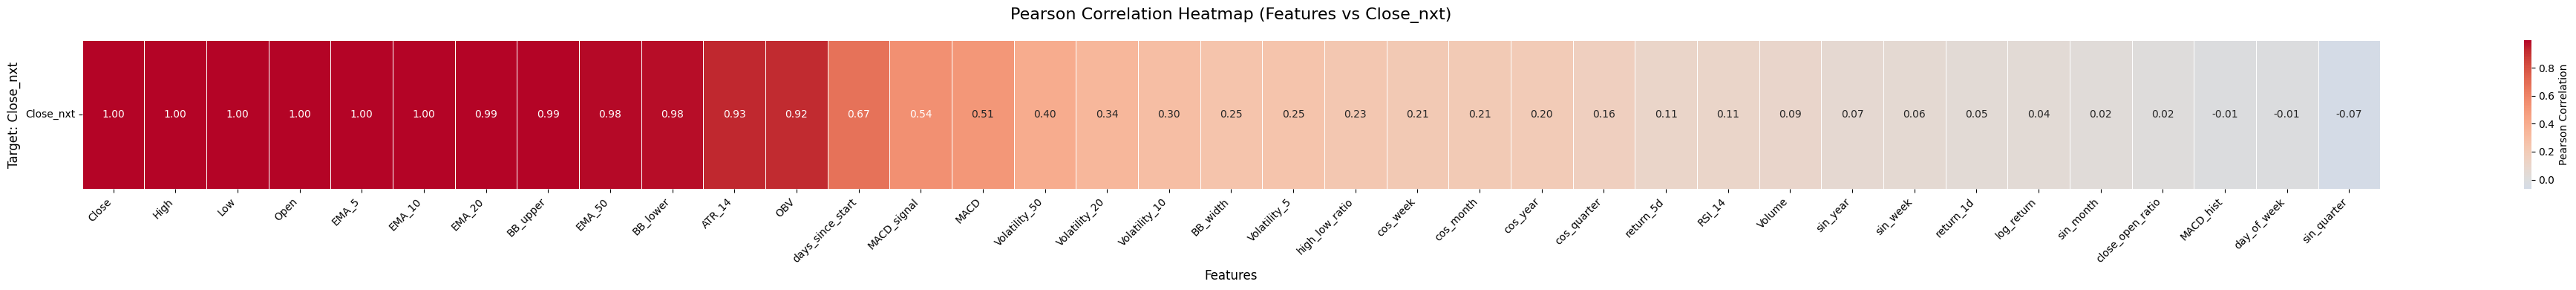

After target filter (>0.25): 19 features
['Close', 'High', 'Low', 'Open', 'EMA_5', 'EMA_10', 'Volatility_10', 'EMA_20', 'Volatility_20', 'EMA_50', 'Volatility_50', 'MACD', 'MACD_signal', 'BB_upper', 'BB_lower', 'BB_width', 'ATR_14', 'OBV', 'days_since_start']


In [6]:
'''Correlation Map Visualization'''
TARGET_THRESHOLD = 0.25
print(f'Before target filter, {len(feature_cols)} features: {feature_cols}')
corr_matrix = sample_df[feature_cols + ['Close_nxt']].corr(method='pearson')
target_corr = corr_matrix['Close_nxt'].abs()
# Plot
plt.figure(figsize=(40, 4))
corr_matrix_for_display = corr_matrix[target_col].drop(target_col).sort_values(by=target_col[0], ascending=False).transpose()
sns.heatmap(corr_matrix_for_display, 
            annot=True, 
            cmap='coolwarm', 
            center=0, 
            fmt='.2f',
            linewidths=0.5,
            cbar_kws={'label': 'Pearson Correlation'})
plt.title("Pearson Correlation Heatmap (Features vs Close_nxt)", fontsize=16, pad=20)
plt.xlabel("Features", fontsize=12)
plt.ylabel("Target: Close_nxt", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

# Create selected_features from correlation filter (matching attempt3.4)
selected_features = [f for f in feature_cols if target_corr[f] > TARGET_THRESHOLD]
print(f"After target filter (>{TARGET_THRESHOLD}): {len(selected_features)} features")

# Update feature cols
feature_cols = selected_features.copy()
print(feature_cols)

In [7]:
'''Unified Feature Selection: Lasso ∪ XGBoost ∪ Granger ∪ LaggedCorr'''
from sklearn.linear_model import Lasso
from xgboost import XGBRegressor
from statsmodels.tsa.stattools import grangercausalitytests

# Prepare sample data
tscv = TimeSeriesSplit(n_splits=5)
X_sample = df[feature_cols].values[:sample_len]
y_flat = y_sample.ravel()

# ── Set A: Lasso (linear, sparse) ──
selection_counts = np.zeros(len(feature_cols), dtype=int)
for train_idx, _ in tscv.split(X_sample):
    lasso = Lasso(alpha=0.01, max_iter=10000, random_state=42)
    lasso.fit(X_sample[train_idx], y_flat[train_idx])
    selection_counts += (lasso.coef_ != 0).astype(int)
set_A = {feature_cols[i] for i, keep in enumerate(selection_counts >= (5 * 2/3)) if keep}

# ── Set B: XGBoost (nonlinear) ──
xgb = XGBRegressor(n_estimators=200, max_depth=5, random_state=42, verbosity=0)
xgb.fit(X_sample, y_flat)
imp = xgb.feature_importances_
thresh = np.percentile(imp, 75)
set_B = {feature_cols[i] for i in range(len(feature_cols)) if imp[i] >= thresh}

# ── Set C: Granger Causality (temporal) ──
skip_cols = {'Close', 'High', 'Low', 'Open', 'Volume', 'BB_upper', 'BB_lower',
             'OBV', 'days_since_start', 'EMA_5', 'EMA_10', 'EMA_20', 'EMA_50'}
stationary_cols = [c for c in feature_cols if c not in skip_cols]
set_C = set()
for col in stationary_cols:
    temp = pd.DataFrame({'target': y_flat[:len(sample_df)],
                         'feature': sample_df[col].values[:len(sample_df)]}).dropna()
    if len(temp) > 50:
        try:
            result = grangercausalitytests(temp[['target', 'feature']], maxlag=5, verbose=False)
            pvals = [result[lag][0]['ssr_ftest'][1] for lag in range(1, 6)]
            if any(p < 0.05 for p in pvals):
                set_C.add(col)
        except:
            pass

# ── Set D: Lagged Correlation (temporal) ──
set_D = set()
for col in feature_cols:
    max_corr = 0
    for lag in range(1, 11):
        corr = sample_df[col].corr(sample_df['Close_nxt'].shift(lag))
        max_corr = max(max_corr, abs(corr))
    if max_corr > 0.3:
        set_D.add(col)

# ── Take Union ──
final_features = list(set_A | set_B | set_C | set_D)
if 'days_since_start' not in final_features:
    final_features.append('days_since_start')

print(f'Lasso (A): {len(set_A)} features → {sorted(set_A)}')
print(f'XGBoost (B): {len(set_B)} features → {sorted(set_B)}')
print(f'Granger (C): {len(set_C)} features → {sorted(set_C)}')
print(f'LaggedCorr (D): {len(set_D)} features → {sorted(set_D)}')

selected_features = final_features
feature_cols = final_features
print(f'Final union: {len(feature_cols)} features → {sorted(feature_cols)}')

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.928e+02, tolerance: 1.122e+01
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not pr

Lasso (A): 5 features → ['BB_lower', 'BB_upper', 'Close', 'OBV', 'days_since_start']
XGBoost (B): 5 features → ['Close', 'EMA_5', 'EMA_50', 'Low', 'Open']
Granger (C): 1 features → ['MACD_signal']
LaggedCorr (D): 17 features → ['ATR_14', 'BB_lower', 'BB_upper', 'Close', 'EMA_10', 'EMA_20', 'EMA_5', 'EMA_50', 'High', 'Low', 'MACD', 'MACD_signal', 'OBV', 'Open', 'Volatility_20', 'Volatility_50', 'days_since_start']
Final union: 17 features → ['ATR_14', 'BB_lower', 'BB_upper', 'Close', 'EMA_10', 'EMA_20', 'EMA_5', 'EMA_50', 'High', 'Low', 'MACD', 'MACD_signal', 'OBV', 'Open', 'Volatility_20', 'Volatility_50', 'days_since_start']


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


---
# 4. Data Preparation (using selected features)
Split **before** scaling to prevent data leakage. Use separate scalers for input features and the target column.

### Train / Val / Test Split

| Split  | Slice                         | Rows              |
|--------|-------------------------------|-------------------|
| Train  | `df[:split_idx_train]`        | 70% of dataset    |
| Val    | `df[split_idx_train:split_idx_val]` | 15% of dataset    |
| Test   | `df[split_idx_val:]`          | 15% of dataset    |


In [8]:
LOOKBACK = 60
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
SEL_EPOCHS = 50
SEL_PATIENCE = 8

feature_cols = selected_features          # from forward selection above
if 'days_since_start' not in feature_cols:
    feature_cols.append('days_since_start')

split_idx_train = int(len(df) * TRAIN_RATIO)
split_idx_val = int(len(df) * (TRAIN_RATIO + VAL_RATIO))

train_features_raw = df[feature_cols].values[:split_idx_train]
val_features_raw   = df[feature_cols].values[split_idx_train:split_idx_val]
test_features_raw  = df[feature_cols].values[split_idx_val:]
train_target_raw   = df[target_col].values[:split_idx_train]
val_target_raw     = df[target_col].values[split_idx_train:split_idx_val]
test_target_raw    = df[target_col].values[split_idx_val:]

scaler = RobustScaler()
target_scaler  = RobustScaler()

# Scale train (fit + transform)
train_features = scaler.fit_transform(train_features_raw)
train_target = target_scaler.fit_transform(train_target_raw)
# Scale val and test (transform only - using train's statistics)
val_features = scaler.transform(val_features_raw)
val_target = target_scaler.transform(val_target_raw)
test_features = scaler.transform(test_features_raw)
test_target = target_scaler.transform(test_target_raw)

print(f'Feature columns ({len(feature_cols)}): {feature_cols}')
print(f'Train: {train_features.shape}  Test: {test_features.shape}')

Feature columns (17): ['EMA_50', 'EMA_10', 'MACD', 'BB_upper', 'ATR_14', 'days_since_start', 'Close', 'MACD_signal', 'EMA_20', 'OBV', 'BB_lower', 'Volatility_50', 'High', 'Low', 'Open', 'Volatility_20', 'EMA_5']
Train: (1806, 17)  Test: (388, 17)


In [9]:
def create_sequences(features, target, lookback):
    X, y = [], []
    for i in range(lookback, len(features)):
        X.append(features[i - lookback:i])
        y.append(target[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_features, train_target, LOOKBACK)
# For val: need padding from train
val_features_padded = np.concatenate([train_features[-LOOKBACK:], val_features])
val_target_padded = np.concatenate([train_target[-LOOKBACK:], val_target])
X_val, y_val = create_sequences(val_features_padded, val_target_padded, LOOKBACK)
# For test: need padding from val  
test_features_padded = np.concatenate([val_features[-LOOKBACK:], test_features])
test_target_padded = np.concatenate([val_target[-LOOKBACK:], test_target])
X_test, y_test = create_sequences(test_features_padded, test_target_padded, LOOKBACK)

print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_test : {X_test.shape}  y_test : {y_test.shape}')

X_train: (1746, 60, 17)  y_train: (1746,)
X_test : (388, 60, 17)  y_test : (388,)


---
# 5. Building and Training LSTM

In [10]:
# Define model builder for KerasTuner
def build_model(hp):
    model = Sequential([
        Input(shape=(LOOKBACK, X_train.shape[2])),
        LSTM(
            hp.Int('units1', min_value=32, max_value=128, step=32),
            return_sequences=True
        ),
        Dropout(hp.Float('dropout', min_value=0.1, max_value=0.3, step=0.1)),
        LSTM(
            hp.Int('units2', min_value=32, max_value=128, step=32),
            return_sequences=False
        ),
        Dropout(hp.Float('dropout', min_value=0.1, max_value=0.3, step=0.1)),
        Dense(1)
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(
            hp.Choice('learning_rate', values=[0.001, 0.0005])
        ),
        loss='mse',
        metrics=['mae']
    )
    return model

# Run Hyperband search
tuner = kt.Hyperband(
    build_model,
    objective='val_loss',
    max_epochs=50,
    factor=3,
    hyperband_iterations=2,
    directory='kt_results',
    project_name='lstm_tuning'
)

# Search with early stopping
tuner.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
    verbose=1,
)

# Get best hyperparameters
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print('Best Hyperparameters:')
print(f'  units1: {best_hp.get("units1")}')
print(f'  units2: {best_hp.get("units2")}')
print(f'  dropout: {best_hp.get("dropout")}')
print(f'  learning_rate: {best_hp.get("learning_rate")}')

Trial 89 Complete [00h 00m 42s]
val_loss: 0.009516171179711819

Best val_loss So Far: 0.006873365957289934
Total elapsed time: 00h 28m 49s
Best Hyperparameters:
  units1: 128
  units2: 128
  dropout: 0.2
  learning_rate: 0.001


In [11]:
# Build final model with best hyperparameters
model = Sequential([
    Input(shape=(LOOKBACK, X_train.shape[2])),
    LSTM(best_hp.get('units1'), return_sequences=True),
    Dropout(best_hp.get('dropout')),
    LSTM(best_hp.get('units2'), return_sequences=False),
    Dropout(best_hp.get('dropout')),
    Dense(1)
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=best_hp.get('learning_rate')),
    loss='mse',
    metrics=['mae']
)

model.summary()

# Train final model
history = model.fit(
    X_train, y_train,
    epochs=100,
    validation_data=(X_val, y_val),
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
    verbose=1
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 128)        │        74,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 206,465 (806.50 KB)

 Trainable params: 206,465 (806.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - loss: 0.0538 - mae: 0.1254 - val_loss: 0.0184 - val_mae: 0.1077
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 0.0125 - mae: 0.0707 - val_loss: 0.0115 - val_mae: 0.0824
Epoch 3/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 0.0092 - mae: 0.0600 - val_loss: 0.0123 - val_mae: 0.0862
Epoch 4/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 0.0079 - mae: 0.0538 - val_loss: 0.0095 - val_mae: 0.0724
Epoch 5/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 0.0079 - mae: 0.0531 - val_loss: 0.0162 - val_mae: 0.1023
Epoch 6/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 0.0072 - mae: 0.0517 - val_loss: 0.0112 - val_mae: 0.0815
Epoch 7/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 0.0064 - mae: 0.0491 - val_loss: 0.0100 - val_mae: 0.0706
Epoch 8/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 0.0061 - mae: 0.0472 - val_loss: 0.0103 - val_mae: 0.0775
Epoch 9/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - lo

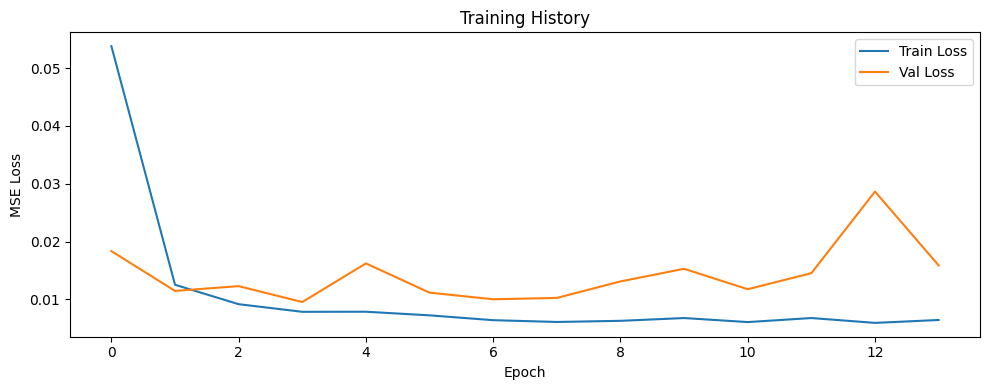

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training History')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

---
# 6. Making Predictions

In [13]:
# --- MC Dropout Prediction ---
N_MC = 50  # number of stochastic forward passes
mc_preds = []
for _ in range(N_MC):
    pred = model(X_test, training=True).numpy()  # keep dropout active
    mc_preds.append(pred)
mc_preds = np.array(mc_preds)  # (N_MC, n_samples, 1)

pred_mean = mc_preds.mean(axis=0)
pred_std  = mc_preds.std(axis=0)

prediction = target_scaler.inverse_transform(pred_mean)
y_test_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1))

# --- Conformal Prediction: calibrate on validation set ---
# Compute MC dropout predictions on validation set
mc_preds_val = []
for _ in range(N_MC):
    pred = model(X_val, training=True).numpy()
    mc_preds_val.append(pred)
mc_preds_val = np.array(mc_preds_val)
pred_mean_val = mc_preds_val.mean(axis=0)

y_val_actual = target_scaler.inverse_transform(y_val.reshape(-1, 1))
pred_val = target_scaler.inverse_transform(pred_mean_val)

# Absolute residuals on calibration (validation) set
abs_resid_val = np.abs(y_val_actual.flatten() - pred_val.flatten())
ALPHA = 0.05  # 95% confidence
q = np.quantile(abs_resid_val, 1 - ALPHA)

# Confidence intervals on test set
ci_lower = prediction.flatten() - q
ci_upper = prediction.flatten() + q

print(f'MC Dropout: {N_MC} passes, pred_mean shape: {prediction.shape}')
print(f'Conformal quantile (95%): {q:.4f}')
print(f'Predictions shape: {prediction.shape}')
print(f'Actuals shape     : {y_test_actual.shape}')


MC Dropout: 50 passes, pred_mean shape: (388, 1)
Conformal quantile (95%): 39.7646
Predictions shape: (388, 1)
Actuals shape     : (388, 1)


---
# 7. Visualisation

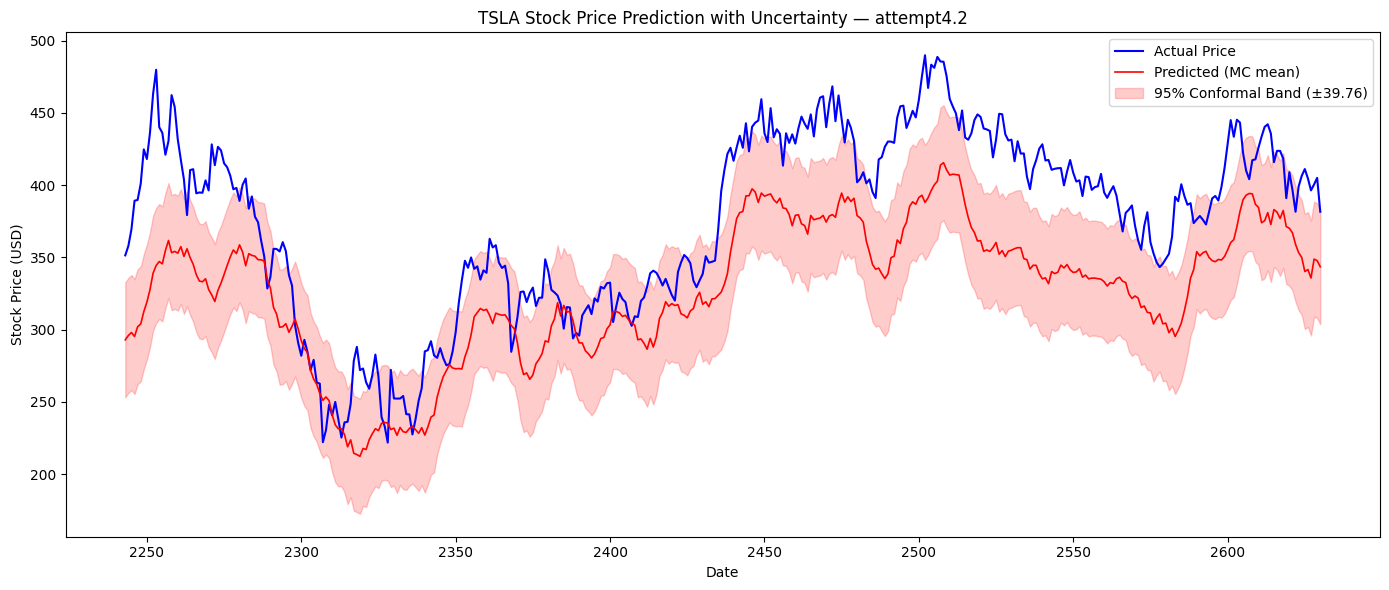

In [14]:
test_dates = df.index[split_idx_val:]     # → 387 rows (85–100% of data)

plt.figure(figsize=(14, 6))
plt.plot(test_dates, y_test_actual.flatten(), label='Actual Price', color='blue', linewidth=1.5)
plt.plot(test_dates, prediction.flatten(), label='Predicted (MC mean)', color='red', linewidth=1.2)
plt.fill_between(test_dates, ci_lower, ci_upper,
                 alpha=0.2, color='red', label=f'95% Conformal Band (±{q:.2f})')
plt.title(f'TSLA Stock Price Prediction with Uncertainty — attempt4.2')
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()


---
# 8. Model Evaluation

In [15]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse  = mean_squared_error(y_test_actual, prediction)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test_actual, prediction)
mape = np.mean(np.abs((y_test_actual - prediction) / y_test_actual)) * 100

# Conformal coverage on test set
covered = (y_test_actual.flatten() >= ci_lower) & (y_test_actual.flatten() <= ci_upper)
coverage = covered.mean() * 100
avg_width = (ci_upper - ci_lower).mean()

print('=' * 55)
print(f'attempt4.2 — LSTM + MC Dropout + Conformal Prediction')
print(f'Features: {feature_cols}')
print('=' * 55)
print(f'  MSE  : {mse:.4f}')
print(f'  RMSE : {rmse:.4f}')
print(f'  MAE  : {mae:.4f}')
print(f'  MAPE : {mape:.2f}%')
print('=' * 55)
print(f'  Conformal coverage (95%): {coverage:.1f}%')
print(f'  Average interval width   : {avg_width:.2f}')
print(f'  Calibration quantile (q) : {q:.4f}')
print('=' * 55)


attempt4.2 — LSTM + MC Dropout + Conformal Prediction
Features: ['EMA_50', 'EMA_10', 'MACD', 'BB_upper', 'ATR_14', 'days_since_start', 'Close', 'MACD_signal', 'EMA_20', 'OBV', 'BB_lower', 'Volatility_50', 'High', 'Low', 'Open', 'Volatility_20', 'EMA_5']
  MSE  : 3052.6504
  RMSE : 55.2508
  MAE  : 48.4659
  MAPE : 12.38%
  Conformal coverage (95%): 36.6%
  Average interval width   : 79.53
  Calibration quantile (q) : 39.7646


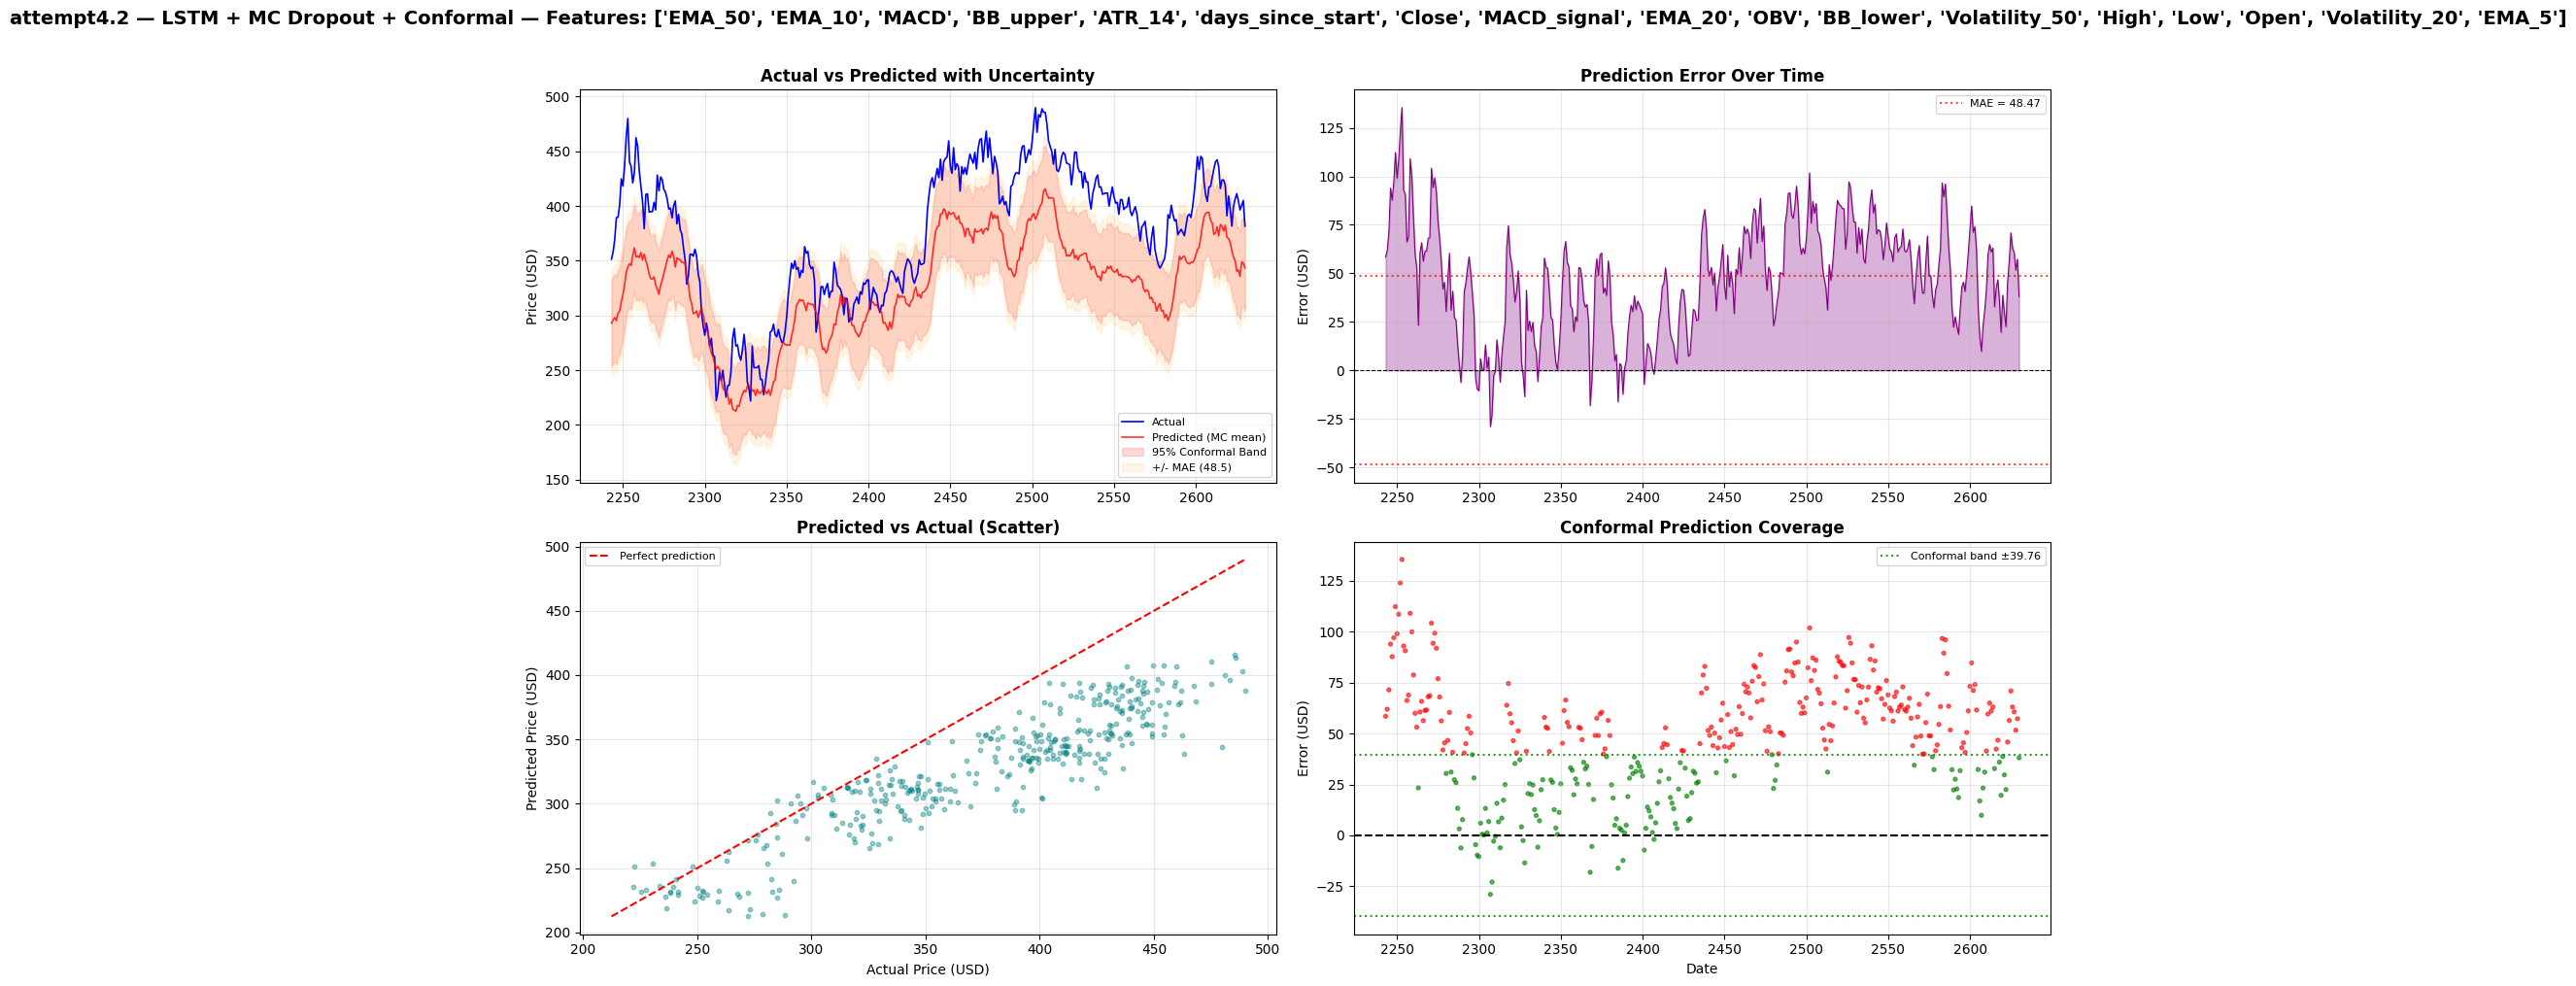

Conformal Coverage (target 95%): 36.6%
Average interval width: 79.53
Mean Error: 47.5640  |  Std Error: 28.1125
Max Over-prediction: 135.4669  |  Max Under-prediction: -28.9667
Mean Abs % Error: 12.38%


In [16]:
test_dates = df.index[split_idx_val:]

mse  = mean_squared_error(y_test_actual, prediction)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test_actual, prediction)
mape = np.mean(np.abs((y_test_actual - prediction) / y_test_actual)) * 100

errors = y_test_actual.flatten() - prediction.flatten()
pct_errors = (errors / y_test_actual.flatten()) * 100
covered = (y_test_actual.flatten() >= ci_lower) & (y_test_actual.flatten() <= ci_upper)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax = axes[0, 0]
ax.plot(test_dates, y_test_actual.flatten(), label='Actual', color='blue', linewidth=1.2)
ax.plot(test_dates, prediction.flatten(), label='Predicted (MC mean)', color='red', linewidth=1.2, alpha=0.8)
ax.fill_between(test_dates, ci_lower, ci_upper,
                alpha=0.15, color='red', label=f'95% Conformal Band')
ax.fill_between(test_dates, prediction.flatten() - mae, prediction.flatten() + mae,
                alpha=0.1, color='orange', label=f'+/- MAE ({mae:.1f})')
ax.set_title('Actual vs Predicted with Uncertainty', fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(test_dates, errors, color='purple', linewidth=0.8)
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax.axhline(y=mae, color='red', linestyle=':', alpha=0.7, label=f'MAE = {mae:.2f}')
ax.axhline(y=-mae, color='red', linestyle=':', alpha=0.7)
ax.fill_between(test_dates, errors, 0, alpha=0.3, color='purple')
ax.set_title('Prediction Error Over Time', fontweight='bold')
ax.set_ylabel('Error (USD)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.scatter(y_test_actual.flatten(), prediction.flatten(), alpha=0.4, s=10, color='teal')
min_val = min(y_test_actual.min(), prediction.min())
max_val = max(y_test_actual.max(), prediction.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Price (USD)')
ax.set_ylabel('Predicted Price (USD)')
ax.set_title('Predicted vs Actual (Scatter)', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1, 1]
# Color by whether covered by conformal band
colors = ['green' if c else 'red' for c in covered]
ax.scatter(test_dates, errors, c=colors, s=8, alpha=0.6)
ax.axhline(y=0, color='black', linestyle='--', linewidth=1.5)
ax.axhline(y=q, color='green', linestyle=':', alpha=0.8, label=f'Conformal band ±{q:.2f}')
ax.axhline(y=-q, color='green', linestyle=':', alpha=0.8)
ax.set_xlabel('Date')
ax.set_ylabel('Error (USD)')
ax.set_title('Conformal Prediction Coverage', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.suptitle(f'attempt4.2 — LSTM + MC Dropout + Conformal — Features: {feature_cols}',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'Conformal Coverage (target 95%): {coverage:.1f}%')
print(f'Average interval width: {avg_width:.2f}')
print(f'Mean Error: {errors.mean():.4f}  |  Std Error: {errors.std():.4f}')
print(f'Max Over-prediction: {errors.max():.4f}  |  Max Under-prediction: {errors.min():.4f}')
print(f'Mean Abs % Error: {np.abs(pct_errors).mean():.2f}%')


---
# 9. Post-hoc Attention Weight Extraction

Extract attention weights from the first LSTM layer to identify which past timesteps
the model focuses on when making predictions.


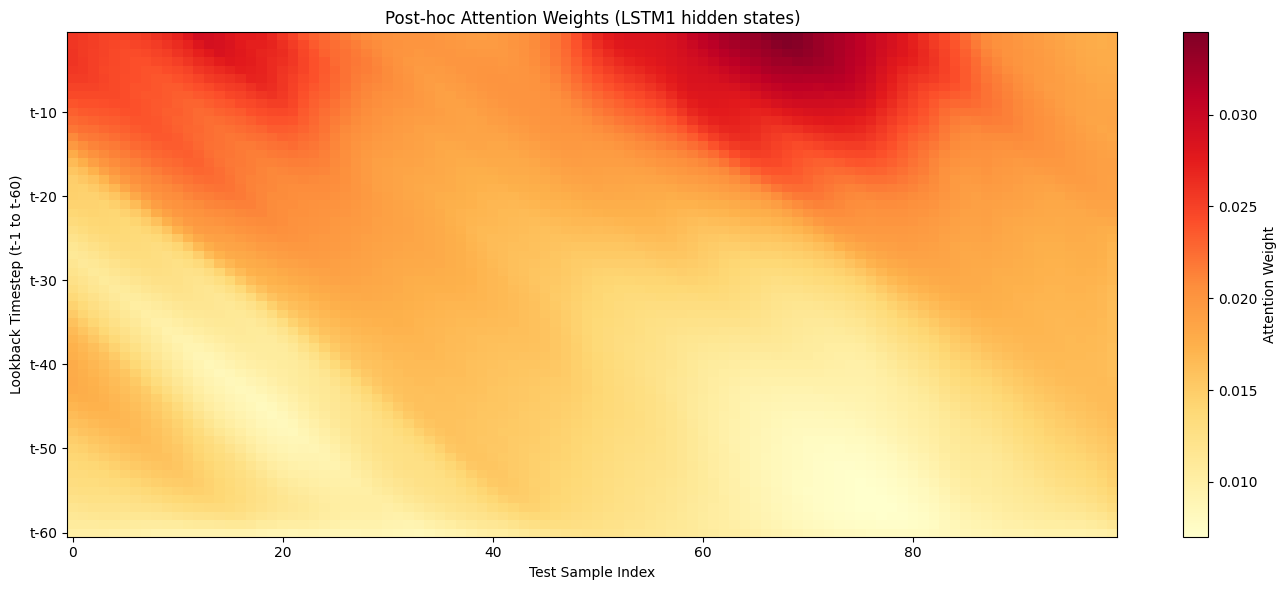

Top-5 most attended lookback positions (averaged across samples):
  1. t-1 (relative importance: 0.0251)
  2. t-2 (relative importance: 0.0251)
  3. t-3 (relative importance: 0.0250)
  4. t-4 (relative importance: 0.0248)
  5. t-5 (relative importance: 0.0246)


In [17]:
from keras.models import Model

# Build a feature model that outputs 1st LSTM hidden states
lstm1_model = Model(
    inputs=model.layers[0].input,
    outputs=model.layers[0].output  # layer 0 = first LSTM (return_sequences=True)
)

# Get hidden states for a batch of test samples
N_ATTN = min(100, len(X_test))
hidden_states = lstm1_model.predict(X_test[:N_ATTN], verbose=0)  # (N_ATTN, 60, 128)

# Compute dot-product attention: compare each timestep h_t with last timestep h_T
# Attention score = softmax(h_T @ h_t^T) — how much does h_t contribute to h_T?
last_h = hidden_states[:, -1:, :]  # (N_ATTN, 1, 128)
scores = np.matmul(hidden_states, last_h.transpose(0, 2, 1)).squeeze(-1)  # (N_ATTN, 60)
scores = scores / np.sqrt(128)  # scale

# Softmax over timesteps
def softmax(x, axis=-1):
    e_x = np.exp(x - x.max(axis=axis, keepdims=True))
    return e_x / e_x.sum(axis=axis, keepdims=True)

attention_weights = softmax(scores, axis=-1)  # (N_ATTN, 60)

# --- Visualize attention heatmap ---
plt.figure(figsize=(14, 6))
plt.imshow(attention_weights.T, aspect='auto', cmap='YlOrRd', origin='lower')
plt.colorbar(label='Attention Weight')
plt.xlabel('Test Sample Index')
plt.ylabel('Lookback Timestep (t-1 to t-60)')
plt.title('Post-hoc Attention Weights (LSTM1 hidden states)')
# Add y-tick labels for every 10 timesteps
tick_pos = np.arange(0, 60, 10)
plt.yticks(tick_pos, [f't-{60-i}' for i in tick_pos])
plt.tight_layout()
plt.show()

# --- Show top-5 most attended timesteps across all samples ---
avg_attention = attention_weights.mean(axis=0)
top5_idx = np.argsort(avg_attention)[-5:][::-1]
print("Top-5 most attended lookback positions (averaged across samples):")
for i, idx in enumerate(top5_idx):
    print(f"  {i+1}. t-{60-idx} (relative importance: {avg_attention[idx]:.4f})")
